In [80]:
import os
from glob import glob
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
from monai.transforms import (
    LoadImaged, EnsureChannelFirstd, Orientationd,
    ResizeWithPadOrCropd, Compose, NormalizeIntensityd
)
from monai.losses import DiceLoss
from monai.metrics import DiceMetric, HausdorffDistanceMetric
from monai.networks.nets import SwinUNETR
from monai.data import Dataset

import tensorflow as tf


In [81]:
### -------------------------------------------
print("TensorFlow GPU:", tf.config.list_physical_devices('GPU'))

###------------------------------------------
  # check if cpu version of python only
print(torch.version.cuda)        # should show e.g., 11.8
print(torch.cuda.is_available()) # should be True
print(torch.cuda.get_device_name(0)) # your GPU name

TensorFlow GPU: []
11.8
True
NVIDIA RTX A4000


In [82]:

# -----------------------------
# Paths (Windows)
# -----------------------------
data_dir = "E:/Dataset/ISLES-2022"
dwi_dir = os.path.join(data_dir, "DWI_NIFTI", "extracted_nii")
mask_dir = os.path.join(data_dir, "MASK_NIFTI", "extracted_nii")


print("DATA DIR:", data_dir)
print("DWI DIR:", dwi_dir)
print("MASK DIR:", mask_dir)

# List files
dwi_files = sorted(glob(os.path.join(dwi_dir, "*.nii")))
mask_files = sorted(glob(os.path.join(mask_dir, "*.nii")))

print(f"Found {len(dwi_files)} DWI images, {len(mask_files)} mask images.")


DATA DIR: E:/Dataset/ISLES-2022
DWI DIR: E:/Dataset/ISLES-2022\DWI_NIFTI\extracted_nii
MASK DIR: E:/Dataset/ISLES-2022\MASK_NIFTI\extracted_nii
Found 250 DWI images, 250 mask images.


DWI shape: (122, 122, 63)
Mask shape: (122, 122, 63)


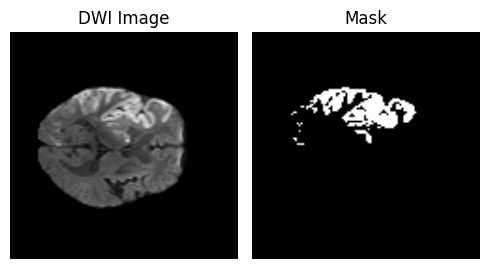

In [83]:
number = 200

# --- Load DWI ---
img_dwi = nib.load(dwi_files[number])
data_dwi = img_dwi.get_fdata()

# --- Load Mask ---
img_mask = nib.load(mask_files[number])
data_mask = img_mask.get_fdata()

print("DWI shape:", data_dwi.shape)
print("Mask shape:", data_mask.shape)

# Choose middle slice (z-axis)
slice_index = data_dwi.shape[2] // 2

# --- Display side by side ---
fig, axes = plt.subplots(1, 2, figsize=(5, 5))

axes[0].imshow(data_dwi[:, :, slice_index], cmap='gray', interpolation='bilinear')
axes[0].set_title("DWI Image")
axes[0].axis('off')

axes[1].imshow(data_mask[:, :, slice_index], cmap='gray', interpolation='bilinear')
axes[1].set_title("Mask")
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [84]:
# -----------------------------
# Preprocessing
# -----------------------------
target_shape = (96,96,96)

# Output folders for preprocessed images
output_dwi_dir = "E:/preprocessed_dwi"
output_mask_dir = "E:/preprocessed_mask"
os.makedirs(output_dwi_dir, exist_ok=True)
os.makedirs(output_mask_dir, exist_ok=True)

resize_transform = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    Orientationd(keys=["image"], axcodes="RAS"),
    ResizeWithPadOrCropd(keys=["image"], spatial_size=target_shape),
    NormalizeIntensityd(keys=["image"], nonzero=True)
])

mask_transform = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    Orientationd(keys=["image"], axcodes="RAS"),
    ResizeWithPadOrCropd(keys=["image"], spatial_size=target_shape)
])

for dwi_path, mask_path in tqdm(zip(dwi_files, mask_files), total=len(dwi_files), desc="Preprocessing"):
    # DWI
    dwi_data = {"image": dwi_path}
    dwi_out = resize_transform(dwi_data)
    dwi_img = dwi_out["image"]
    dwi_np = dwi_img[0].numpy()
    dwi_affine = nib.load(dwi_path).affine
    nib.save(nib.Nifti1Image(dwi_np, dwi_affine), os.path.join(output_dwi_dir, os.path.basename(dwi_path)))

    # Mask
    mask_data = {"image": mask_path}
    mask_out = mask_transform(mask_data)
    mask_img = mask_out["image"]
    mask_np = mask_img[0].numpy()
    mask_affine = nib.load(mask_path).affine
    nib.save(nib.Nifti1Image(mask_np, mask_affine), os.path.join(output_mask_dir, os.path.basename(mask_path)))


c:\Users\FAST\Desktop\swin Factorizer\venv\Lib\site-packages\monai\utils\deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)
Preprocessing: 100%|██████████| 250/250 [00:18<00:00, 13.74it/s]


DWI shape: (96, 96, 96)
Mask shape: (96, 96, 96)


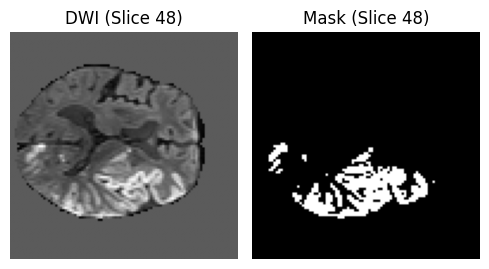

In [85]:
#After preprocessing
idx = 200

dwi_path = sorted(os.listdir(output_dwi_dir))[idx]
mask_path = sorted(os.listdir(output_mask_dir))[idx]

dwi_img = nib.load(os.path.join(output_dwi_dir, dwi_path))
mask_img = nib.load(os.path.join(output_mask_dir, mask_path))

dwi_data = dwi_img.get_fdata()
mask_data = mask_img.get_fdata()

print("DWI shape:", dwi_data.shape)
print("Mask shape:", mask_data.shape)

# Pick a slice from the middle
slice_idx = dwi_data.shape[2] // 2

# Plot DWI and mask side by side
fig, axes = plt.subplots(1, 2, figsize=(5, 5))

axes[0].imshow(dwi_data[:, :, slice_idx], cmap='gray')
axes[0].set_title('DWI (Slice {})'.format(slice_idx))
axes[0].axis('off')

axes[1].imshow(mask_data[:, :, slice_idx], cmap='gray')
axes[1].set_title('Mask (Slice {})'.format(slice_idx))
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [86]:
# -----------------------------
# Train/Validation split
# -----------------------------
preprocessed_dwi_files = sorted(glob(os.path.join(output_dwi_dir, "*.nii")))
preprocessed_mask_files = sorted(glob(os.path.join(output_mask_dir, "*.nii")))

train_dwi, val_dwi, train_mask, val_mask = train_test_split(
    preprocessed_dwi_files, preprocessed_mask_files, test_size=0.2, random_state=42
)

train_files = [{"image": i, "mask": m} for i, m in zip(train_dwi, train_mask)]
val_files = [{"image": i, "mask": m} for i, m in zip(val_dwi, val_mask)]

train_transforms = Compose([LoadImaged(keys=["image","mask"]), EnsureChannelFirstd(keys=["image","mask"])])
val_transforms = Compose([LoadImaged(keys=["image","mask"]), EnsureChannelFirstd(keys=["image","mask"])])

train_ds = Dataset(data=train_files, transform=train_transforms)
val_ds = Dataset(data=val_files, transform=val_transforms)

train_loader = DataLoader(train_ds, batch_size=2, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=2, shuffle=False)

for batch in train_loader:
    images = batch["image"]  # shape: (B, C, H, W, D)
    masks  = batch["mask"]   # shape: (B, C, H, W, D)

    print("Images shape:", images.shape)
    print("Masks shape:", masks.shape)

    # single sample
    image_sample = images[0]
    mask_sample = masks[0]

    print("Single image shape:", image_sample.shape)  # (1, H, W, D)
    print("Single mask shape:", mask_sample.shape)    # (1, H, W, D)
    break #print only first element of the first batch

Images shape: torch.Size([2, 1, 96, 96, 96])
Masks shape: torch.Size([2, 1, 96, 96, 96])
Single image shape: torch.Size([1, 96, 96, 96])
Single mask shape: torch.Size([1, 96, 96, 96])


In [87]:
import torch
import nibabel as nib

total_pos = 0.0
total_neg = 0.0

for file_path in preprocessed_mask_files:
    # Load NIfTI mask as NumPy array
    mask = nib.load(file_path).get_fdata()  
    mask = torch.tensor(mask, dtype=torch.float32)
    
    total_pos += mask.sum()            # lesion voxels
    total_neg += (1 - mask).sum()      # background voxels

    print(total_neg,total_pos)

# Compute pos_weight
pos_weight_value = total_neg / total_pos
print(f"Recommended pos_weight: {pos_weight_value}")

tensor(883901.) tensor(835.)
tensor(1768519.) tensor(953.)
tensor(2649382.) tensor(4826.)
tensor(3533837.) tensor(5107.)
tensor(4417845.) tensor(5835.)
tensor(5302576.) tensor(5840.)
tensor(6186873.) tensor(6279.)
tensor(7071515.) tensor(6373.)
tensor(7955728.) tensor(6896.)
tensor(8840043.) tensor(7317.)
tensor(9723380.) tensor(8716.)
tensor(10608060.) tensor(8772.)
tensor(11489151.) tensor(12417.)
tensor(12372338.) tensor(13966.)
tensor(13255423.) tensor(15617.)
tensor(14140133.) tensor(15643.)
tensor(15022940.) tensor(17572.)
tensor(15907543.) tensor(17705.)
tensor(16783708.) tensor(26277.)
tensor(17667336.) tensor(27384.)
tensor(18549856.) tensor(29599.)
tensor(19434428.) tensor(29762.)
tensor(20258896.) tensor(90031.)
tensor(21140628.) tensor(93036.)
tensor(22024396.) tensor(94005.)
tensor(22908680.) tensor(94456.)
tensor(23792594.) tensor(95278.)
tensor(24676420.) tensor(96187.)
tensor(25560060.) tensor(97282.)
tensor(26444732.) tensor(97346.)
tensor(27317834.) tensor(108980.)
te

In [88]:
pos = mask_sample.sum().item()        # number of positive pixels
neg = mask_sample.numel() - pos       # total pixels - positive pixels
print("pos_weight =", neg / pos)


pos_weight = 4335.941176470588


In [89]:
# -----------------------------
# Device
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [90]:
!pip install git+https://github.com/pashtari/factorizer.git

  Cloning https://github.com/pashtari/factorizer.git to c:\users\fast\appdata\local\temp\pip-req-build-t5jamkyz
  Resolved https://github.com/pashtari/factorizer.git to commit 9adcc5d3c5178d458f5720125ce450e7696f1e09
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'


  Running command git clone --filter=blob:none --quiet https://github.com/pashtari/factorizer.git 'C:\Users\FAST\AppData\Local\Temp\pip-req-build-t5jamkyz'


In [91]:
import factorizer as ft

In [92]:
# #factorizer block 
# factorizer_block = ft.FactorizerBlock(
#     channels=32,
#     spatial_size=target_shape,      
#     norm=ft.LayerNorm,
#     reshape=(ft.SWMatricize, {'head_dim': 8, 'patch_size': 8}),
#     act=nn.ReLU,
#     factorize=ft.NMF,
#     rank=4,                    # increase rank for more expressive features
#     num_iters=5,
#     init="uniform",
#     solver="hals",
#     mlp_ratio=2,
#     dropout=0.1
# )

In [93]:

# -----------------------------
# Model
# -----------------------------
model = ft.Factorizer(
    in_channels=1,
    out_channels=1,
    spatial_size=target_shape,
    encoder_depth=(1, 1, 1, 1),
    encoder_width=(32, 64, 128, 256),
    strides=(1, 2, 2, 2, 2),
    decoder_depth=(1, 1, 1, 1),
    norm=ft.LayerNorm,
    reshape=(ft.SWMatricize, {'head_dim': 8, 'patch_size': 2}),
    act=nn.ReLU,
    factorize=ft.NMF, 
    rank=1,
    num_iters=3,
    init="uniform",
    solver="hals",
    mlp_ratio=2,
    dropout=0.1
).to(device)

pos_weight = torch.tensor([8]).to(device)
bce_loss = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
dice_loss = DiceLoss(sigmoid=True)

def loss_function(y_pred, y_true):
    return 0.7 * dice_loss(y_pred, y_true) + 0.3 * bce_loss(y_pred, y_true)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
dice_metric = DiceMetric(include_background=False, reduction="mean")
hd_metric = HausdorffDistanceMetric(include_background=False, percentile=95, reduction="mean")

def iou_from_dice(dice):
    return dice / (2 - dice)


In [94]:
print([x for x in dir(ft) if "c" in x.lower()])


['BCDSolver', 'BasicBlock', 'Callable', 'Compose', 'ContextManager', 'CoordinateDescent', 'DoubleConv', 'FactMixer', 'Factorizer', 'FactorizerBlock', 'FactorizerStage', 'FastMultiplicativeUpdate', 'FuzzyCMeans', 'INIT_DISPATCH_MAP', 'Matricize', 'MatrixFactorization', 'MultiplicativeUpdate', 'PartialFunctionType', 'PreActivationBlock', 'ProjectedGradient', 'SOLVER_DISPATCH_MAP', 'SWMatricize', 'SemiMultiplicativeUpdate', 'SepConv', 'Sequence', 'UNetDecoder', 'UNetDecoderBlock', 'UNetEncoder', 'UNetEncoderBlock', 'WeightedMultiplicativeUpdate', '__cached__', '__doc__', '__package__', '__spec__', 'accumulate', 'conv', 'cumprod', 'factorization', 'factorizer', 'inspect', 'kl_divergence', 'matrix_factorization', 'nullcontext', 'reduce', 'torch']


In [95]:
print(model)

Factorizer(
  (stem): Conv3d(1, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
  (encoder): UNetEncoder(
    (blocks): ModuleList(
      (0): UNetEncoderBlock(
        (downsample): Identity()
        (block): FactorizerStage(
          (pos_embed): Identity()
          (blocks): ModuleList(
            (0): FactorizerBlock(
              (norm1): LayerNorm(
                (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
              )
              (fact): FactMixer(
                (in_proj): Linear(
                  (flatten): Flatten(start_dim=2, end_dim=-1)
                  (linear): Conv1d(32, 32, kernel_size=(1,), stride=(1,), bias=False)
                )
                (reshape): SWMatricize(
                  (shifted_windows): ModuleList(
                    (0-1): 2 x Matricize(
                      (rearrange): Rearrange('b (h d) (g0 p0) (g1 p1) (g2 p2) -> (b h) (g0 g1 g2) d (p0 p1 p2)', d=8, p0=2, p1=2, p2=2)
                

In [96]:
# -----------------------------
# Checkpoints & TensorBoard logs
# -----------------------------
checkpoint_dir = "E:/SwinFactorizer_SingleChannel_checkpoints"
log_dir = "E:/SwinFactorizer_SingleCahnnel_logs"
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(log_dir, exist_ok=True)
writer = SummaryWriter(log_dir=log_dir)

print(f"Checkpoints will be saved to: {checkpoint_dir}")
print(f"TensorBoard logs will be saved to: {log_dir}")


Checkpoints will be saved to: E:/SwinFactorizer_SingleChannel_checkpoints
TensorBoard logs will be saved to: E:/SwinFactorizer_SingleCahnnel_logs


In [97]:

# -----------------------------
# Training loop
# -----------------------------
best_dice = 0.0
history = {"train_loss": [], "val_loss":[], "val_dice": [], "val_iou": [], "val_hd95": []}
num_epochs = 50

for epoch in range(1, num_epochs+1):
    model.train()
    epoch_loss = 0
    for batch_idx, batch in enumerate(tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs}", leave=False)):
        images = batch["image"].to(device, dtype=torch.float32)
        masks = batch["mask"].to(device, dtype=torch.float32)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_function(outputs, masks)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        writer.add_scalar("train/loss_batch", loss.item(), epoch * len(train_loader) + batch_idx)

    avg_train_loss = epoch_loss / len(train_loader)
    history["train_loss"].append(avg_train_loss)
    writer.add_scalar("train/loss_epoch", avg_train_loss, epoch)

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for val_batch in val_loader:
            val_images = val_batch["image"].to(device, dtype=torch.float32)
            val_masks = val_batch["mask"].to(device, dtype=torch.float32)

            val_outputs = model(val_images)
            loss_val = loss_function(val_outputs, val_masks)
            val_loss += loss_val.item()

            pred_binary = (torch.sigmoid(val_outputs) > 0.5).float()
            dice_metric(y_pred=pred_binary, y=val_masks)
            hd_metric(y_pred=pred_binary, y=val_masks)

    avg_val_loss = val_loss / len(val_loader)
    mean_dice = dice_metric.aggregate().item()
    mean_hd95 = hd_metric.aggregate().item()
    mean_iou = iou_from_dice(mean_dice)

    dice_metric.reset()
    hd_metric.reset()

    history["val_loss"].append(avg_val_loss)
    history["val_dice"].append(mean_dice)
    history["val_iou"].append(mean_iou)
    history["val_hd95"].append(mean_hd95)

    writer.add_scalar("val/loss_epoch", avg_val_loss, epoch)
    writer.add_scalar("val/dice", mean_dice, epoch)
    writer.add_scalar("val/iou", mean_iou, epoch)
    writer.add_scalar("val/hd95", mean_hd95, epoch)
    writer.flush()

    print(f"Epoch {epoch}: Train Loss={avg_train_loss:.4f} | Val Loss={avg_val_loss:.4f} | DSC={mean_dice:.4f} | IoU={mean_iou:.4f} | HD95={mean_hd95:.4f}")

    # Save best model
    if mean_dice > best_dice:
        best_dice = mean_dice
        best_model_path = os.path.join(checkpoint_dir, "best_model.pth")
        torch.save(model.state_dict(), best_model_path)
        print(f"Best model updated at epoch {epoch} with DSC={best_dice:.4f}")

writer.close()

c:\Users\FAST\Desktop\swin Factorizer\venv\Lib\site-packages\monai\utils\deprecate_utils.py:221: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)
c:\Users\FAST\Desktop\swin Factorizer\venv\Lib\site-packages\monai\metrics\utils.py:332: UserWarning: the prediction of class 0 is all 0, this may result in nan/inf distance.
  warnings.warn(


Epoch 1: Train Loss=0.7523 | Val Loss=0.6230 | DSC=0.1413 | IoU=0.0760 | HD95=34.7744
Best model updated at epoch 1 with DSC=0.1413


Epoch 2: Train Loss=0.5553 | Val Loss=0.6001 | DSC=0.1931 | IoU=0.1068 | HD95=37.3974
Best model updated at epoch 2 with DSC=0.1931


Epoch 3: Train Loss=0.5235 | Val Loss=0.5691 | DSC=0.2241 | IoU=0.1262 | HD95=37.6342
Best model updated at epoch 3 with DSC=0.2241


Epoch 4: Train Loss=0.5015 | Val Loss=0.5431 | DSC=0.2545 | IoU=0.1458 | HD95=36.7146
Best model updated at epoch 4 with DSC=0.2545


...

Epoch 46: Train Loss=0.1615 | Val Loss=0.2931 | DSC=0.6078 | IoU=0.4365 | HD95=16.6836


Epoch 47: Train Loss=0.1506 | Val Loss=0.2791 | DSC=0.6287 | IoU=0.4585 | HD95=13.9543
Best model updated at epoch 47 with DSC=0.6287


Epoch 48: Train Loss=0.1500 | Val Loss=0.2845 | DSC=0.6219 | IoU=0.4512 | HD95=12.8430


Epoch 49: Train Loss=0.1477 | Val Loss=0.2724 | DSC=0.6389 | IoU=0.4694 | HD95=14.4329
Best model updated at epoch 49 with DSC=0.6389


Epoch 50: Train Loss=0.1454 | Val Loss=0.2973 | DSC=0.6049 | IoU=0.4336 | HD95=16.2496


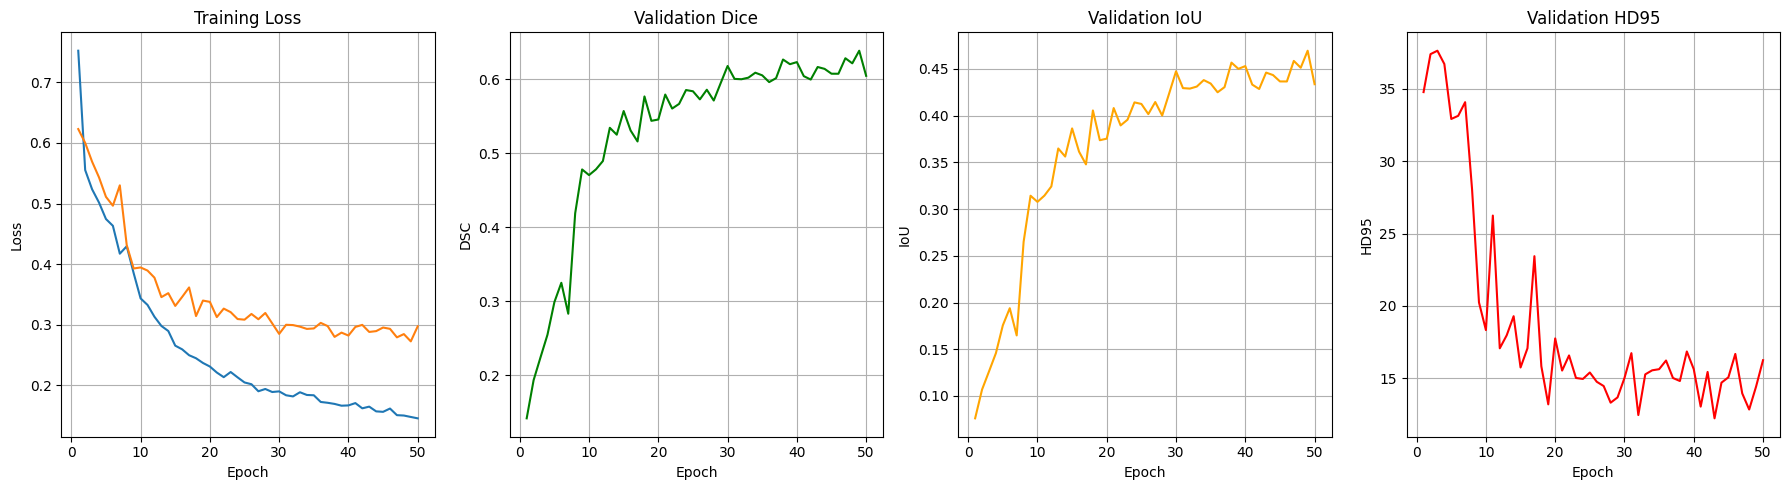

In [98]:
# ----------------------------
# Plot Training & Metrics
# ----------------------------
epochs = range(1, num_epochs+1)
plt.figure(figsize=(18,5))

# Training Loss
plt.subplot(1,4,1)
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)

# Dice
plt.subplot(1,4,2)
plt.plot(epochs, history["val_dice"], label="Validation DSC", color="green")
plt.xlabel("Epoch")
plt.ylabel("DSC")
plt.title("Validation Dice")
plt.grid(True)

# IoU
plt.subplot(1,4,3)
plt.plot(epochs, history["val_iou"], label="Validation IoU", color="orange")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title("Validation IoU")
plt.grid(True)

# HD95
plt.subplot(1,4,4)
plt.plot(epochs, history["val_hd95"], label="Validation HD95", color="red")
plt.xlabel("Epoch")
plt.ylabel("HD95")
plt.title("Validation HD95")
plt.grid(True)

plt.tight_layout()
plt.show()

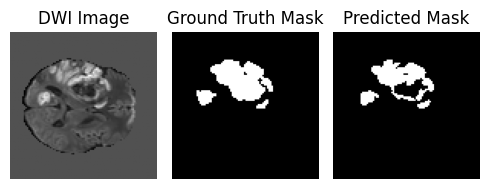

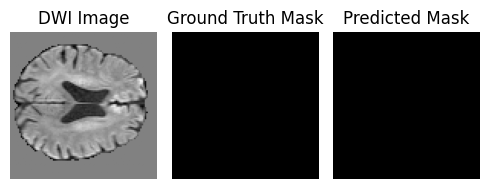

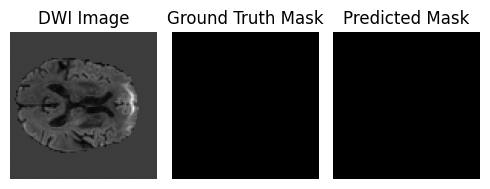

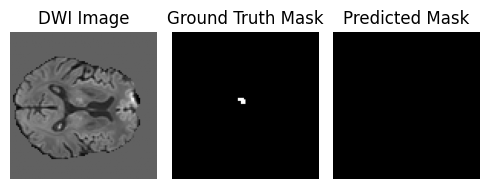

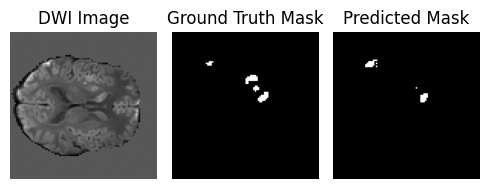

In [103]:
import random
def visualize_3d_predictions(model, dataset, device, num_samples=3):
    """
    Visualize num_samples random 3D volumes from the dataset.
    For each volume, show one slice: image, ground truth mask, predicted mask.
    """
    model.eval()
    indices = random.sample(range(len(dataset)), num_samples)
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            data = dataset[idx]
            img = data["image"].unsqueeze(0).to(device, dtype=torch.float32)  # [1, C, H, W, D]
            mask = data["mask"]  # tensor [C, H, W, D]

            # Model prediction
            pred = model(img)
            pred_sigmoid = torch.sigmoid(pred)[0,0].cpu()  # [H, W, D]

            # Pick middle slice along z-axis
            z = img.shape[-1] // 2
            img_slice = img[0,0,:,:,z].cpu().numpy()
            mask_slice = mask[0,:,:,z].numpy()
            pred_slice = (pred_sigmoid[:,:,z] > 0.5).numpy()  # binary mask

            # Plot
            plt.figure(figsize=(5,5))
            plt.subplot(1,3,1)
            plt.imshow(img_slice, cmap='gray')
            plt.title("DWI Image")
            plt.axis('off')

            plt.subplot(1,3,2)
            plt.imshow(mask_slice, cmap='gray')
            plt.title("Ground Truth Mask")
            plt.axis('off')

            plt.subplot(1,3,3)
            plt.imshow(pred_slice, cmap='gray')
            plt.title("Predicted Mask")
            plt.axis('off')

            plt.tight_layout()
            plt.show()
visualize_3d_predictions(model, val_ds, device, num_samples=5)

In [104]:
%load_ext tensorboard
%tensorboard --logdir E:/SwinFactorizer_SingleChannel_logs

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 19448), started 16:13:17 ago. (Use '!kill 19448' to kill it.)